In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch
from datasets import Dataset
from setfit import SetFitModel
from setfit import SetFitTrainer

import re
import time
import requests
import trafilatura
from datetime import datetime, timedelta
from collections import defaultdict
import matplotlib.pyplot as plt
from urllib.parse import urlparse


In [2]:


df = pd.read_csv("Test_Data.csv",index_col=False)
df["label"] = df["label"].astype(str).str.strip().str.lower()

#split model into train and test and cv - stratified 

train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

#encode labels

label2id = {"down": 0, "neutral": 1, "up": 2}
id2label = {v: k for k, v in label2id.items()}

for df_part in [train_df, val_df, test_df]:
    df_part["label"] = df_part["label"].map(label2id)

#convert to hugging face datasets


train_ds = Dataset.from_pandas(train_df[["text", "label"]])
val_ds = Dataset.from_pandas(val_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

#load Setfit

model = SetFitModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

#Train Setfit


trainer = SetFitTrainer(
    model=model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    metric="f1",
    batch_size=16,
    num_iterations=20,   # how many contrastive steps
    num_epochs=1         # classifier training
)

trainer.train()


#eval model

preds = trainer.model(test_ds["text"])
true = test_ds["label"]

print("Accuracy:", accuracy_score(true, preds))
print("Macro F1:", f1_score(true, preds, average="macro"))



model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
C:\Users\joven\AppData\Local\Temp\ipykernel_33132\1606272256.py:36: DeprecationWarning: `SetFitTrainer` has been deprecated and will be removed in v2.0.0 of SetFit. Please use `Trainer` instead.
  trainer = SetFitTrainer(


Map:   0%|          | 0/109 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 4360
  Batch size = 16
  Num epochs = 1
c:\Users\joven\miniconda3\envs\setfit\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
1,0.258900
50,0.225500
100,0.175100
150,0.085100
200,0.032400
250,0.020700


Accuracy: 0.7916666666666666
Macro F1: 0.7925925925925927


In [7]:

FINANCE_KEYWORDS = {
    "inflation", "cpi", "core inflation", "price pressures", "prices",
    "interest rate", "interest rates", "rate hike", "rate cut",
    "bank of england", "boe", "federal reserve", "fed", "ecb",
    "monetary policy", "tightening", "easing", "hawkish", "dovish",
    "wages", "labour market", "labor market", "consumer prices", "central bank"
}

SENTENCE_KEYWORDS = {
    "inflation", "cpi", "core inflation", "interest rate", "interest rates",
    "rate hike", "rate cut", "bank of england", "boe", "federal reserve", "fed",
    "ecb", "central bank", "monetary policy", "tightening", "easing",
    "hawkish", "dovish", "wages", "prices", "consumer prices",
    "sticky inflation", "services inflation", "disinflation"
}

FORWARD_LOOKING_KEYWORDS = {
    "expect", "expected", "expects", "forecast", "forecasts", "projected",
    "outlook", "likely", "unlikely", "could", "may", "might", "should",
    "anticipated", "anticipate", "signals", "signalled", "guidance"
}


def weighted_sentiment(probs,entropy):

    """
    probs: array of shape (n_sentences, 3)
        columns = [p_up, p_neutral, p_down]
    """

    #extract probs
    p_up = probs[:, 2]
    #p_neutral = probs[:, 1]  --- IGNORE ---
    p_down = probs[:, 0]

    #calculate score
    scores = p_up - p_down

    #normalise entropy
    H = entropy
    H_norm = H / np.log(3.0)

    #calculate weighted score 
    weights = np.abs(p_up - p_down) * (1 - H_norm)
    total_weights = np.sum(weights)

    #calculate weighted probabilities  
    weightedp_up = np.average(p_up, weights=weights) if total_weights > 0 else None
    weightedp_down = np.average(p_down, weights=weights) if total_weights > 0 else None
    
    if total_weights == 0:
            return 0.0, 0.0, 0.0, 0.0

    return np.sum(weights * scores) / total_weights, total_weights, weightedp_up, weightedp_down

#build rates expectations index - Ei = P_up - P_down, 

def rates_expectations(model, texts, labels=("down","neutral","up")):

    """
    Computes rate expectation scores from text using a SetFit model.

    Returns:
        dict with:
        - scores: per-text (p_up - p_down)
        - mean_score: aggregate expectation
        - probs: full probability matrix
        - predictions: predicted labels
        - confidence: confidence of predicted class
    """

    # Get probabilities
    probs = model.predict_proba(texts)

    #convert to numpy array 
    if isinstance(probs, torch.Tensor):
        probs = probs.detach().cpu().numpy()
    else:
        probs = np.asarray(probs)

    # Predictions + confidence
    pred_idx = np.argmax(probs, axis=1)
    predictions = [labels[i] for i in pred_idx]
    confidence = probs[np.arange(len(probs)), pred_idx]
    entropy = -np.sum(probs* np.log(probs + 1e-10), axis=1)

    text_sentiment_score, total_weights, weightedp_up, weightedp_down = weighted_sentiment(probs, entropy)

    values_dict = {
        "weighted_score": text_sentiment_score,
        "total_weights": total_weights,
        "entropy": entropy,
        "probs": probs,
        "predictions": predictions,
        "confidence": confidence,
        "weightedp_up": weightedp_up,
        "weightedp_down": weightedp_down
     }


    return text_sentiment_score,total_weights, values_dict

import requests
import time

def fetch_gnews_articles(
    api_key,
    query,
    from_date=None,
    to_date=None,
    page_size=10,
    pages=1,
    language="en",
    search_in="title,description",
    sort_by="publishedAt"
):
    url = "https://gnews.io/api/v4/search"
    all_articles = []

    for page in range(1, pages + 1):
        params = {
            "q": query,
            "lang": language,
            "max": page_size,
            "page": page,
            "sortby": sort_by,
            "in": search_in,
            "apikey": api_key,
        }

        if from_date:
            params["from"] = from_date
        if to_date:
            params["to"] = to_date

        try:
            r = requests.get(url, params=params, timeout=20)
            r.raise_for_status()
        except requests.exceptions.ConnectionError as e:
            raise RuntimeError(
                "Network/DNS error reaching gnews.io. "
                "Check internet, DNS, VPN, firewall, or proxy settings."
            ) from e
        except requests.exceptions.HTTPError as e:
            print("HTTP status:", r.status_code)
            print("Response text:", r.text[:1000])
            raise

        data = r.json()
        articles = data.get("articles", [])
        all_articles.extend(articles)

        if len(articles) < page_size:
            break

        time.sleep(0.5)

    return all_articles


def extract_domain(url):
    if not url:
        return None
    netloc = urlparse(url).netloc.lower()
    if netloc.startswith("www."):
        netloc = netloc[4:]
    return netloc


def article_matches_domain(article, allowed_domains=None, blocked_domains=None):
    allowed_domains = set(d.lower() for d in (allowed_domains or []))
    blocked_domains = set(d.lower() for d in (blocked_domains or []))

    source_url = (article.get("source") or {}).get("url")
    article_url = article.get("url")

    domain = extract_domain(source_url) or extract_domain(article_url)
    if domain is None:
        return False

    def matches(domain, domain_list):
        return any(domain == d or domain.endswith("." + d) for d in domain_list)

    if allowed_domains and not matches(domain, allowed_domains):
        return False

    if blocked_domains and matches(domain, blocked_domains):
        return False

    return True


def is_financial_or_inflation_related(title, description=""):
    text = f"{title or ''} {description or ''}".lower()
    return any(keyword in text for keyword in FINANCE_KEYWORDS)


def extract_article_text(url):
    """
    Download and extract main article text using Trafilatura.
    Returns None if extraction fails.
    """
    downloaded = trafilatura.fetch_url(url)
    if not downloaded:
        return None

    text = trafilatura.extract(
        downloaded,
        favor_precision=True,
        include_comments=False
    )
    return text


def split_into_sentences(text):
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sentences if s.strip()]


def sentence_score(sentence, title=""):
    """
    Score a sentence for relevance.
    Higher score = more likely useful for inflation / policy sentiment analysis.
    """
    s_lower = sentence.lower()
    title_lower = (title or "").lower()

    # basic keyword hits
    keyword_score = sum(kw in s_lower for kw in SENTENCE_KEYWORDS)

    # forward-looking language is often more useful for market sentiment
    forward_score = sum(kw in s_lower for kw in FORWARD_LOOKING_KEYWORDS)

    # overlap with title words
    title_words = set(re.findall(r"\b[a-z]{4,}\b", title_lower))
    sent_words = set(re.findall(r"\b[a-z]{4,}\b", s_lower))
    overlap_score = len(title_words & sent_words)

    # prefer medium-length sentences over tiny useless fragments
    word_count = len(sentence.split())
    if 8 <= word_count <= 40:
        length_score = 2
    elif 5 <= word_count <= 60:
        length_score = 1
    else:
        length_score = 0

    return (
        3 * keyword_score
        + 2 * forward_score
        + overlap_score
        + length_score
    )


def extract_key_sentences(text, title="", max_sentences=5, min_score=2):
    """
    Extract top-N relevant sentences from article text.
    """
    sentences = split_into_sentences(text)
    scored = []

    for i, s in enumerate(sentences):
        score = sentence_score(s, title=title)

        # slight preference for earlier sentences because journalists
        # keep pretending the important bit belongs near the top
        position_bonus = max(0, 2 - i * 0.1)
        total_score = score + position_bonus

        if total_score >= min_score:
            scored.append((total_score, s))

    scored.sort(key=lambda x: x[0], reverse=True)

    chosen = []
    seen = set()
    for _, s in scored:
        if s not in seen:
            chosen.append(s)
            seen.add(s)
        if len(chosen) >= max_sentences:
            break

    return chosen


def parse_article_day(article):
    published = article.get("publishedAt")
    if not published:
        return None
    # publishedAt usually looks like 2026-04-03T12:34:56Z
    return published[:10]


def default_sentiment_function(text):
    """
    Placeholder.
    Replace this with your trained model function.
    Should return a scalar score, e.g.:
      negative = -1
      neutral  = 0
      positive = +1
    or a continuous score.
    """
    return 0.0


def inter_article_directional_entropy(P_up, P_down, weights):
    P_up = np.array(P_up)
    P_down = np.array(P_down)
    weights = np.array(weights)

    total_weight = np.sum(weights)
    if total_weight == 0:
        return 0.0

    P_up_bar = np.sum(weights * P_up) / total_weight
    P_down_bar = np.sum(weights * P_down) / total_weight

    directional_mass = P_up_bar + P_down_bar
    if directional_mass <= 0:
        return 0.0

    p_up_dir = P_up_bar / directional_mass
    p_down_dir = P_down_bar / directional_mass

    probs = np.array([p_up_dir, p_down_dir])
    probs = np.clip(probs, 1e-12, 1.0)

    H = -np.sum(probs * np.log(probs))
    H_norm = H / np.log(2.0)

    return H_norm


def inter_article_entropy(P_up, P_down, weights):
    P_up = np.array(P_up)
    P_down = np.array(P_down)
    weights = np.array(weights)

    P_neutral = 1 - (P_up + P_down)

    total_weight = np.sum(weights)

    if total_weight == 0:
        return 0.0

    # weighted average probabilities
    P_up_bar = np.sum(weights * P_up) / total_weight
    P_down_bar = np.sum(weights * P_down) / total_weight
    P_neutral_bar = np.sum(weights * P_neutral) / total_weight

    probs = np.array([P_up_bar, P_neutral_bar, P_down_bar])
    probs = np.clip(probs, 1e-12, 1.0)

    H = -np.sum(probs * np.log(probs))
    H_norm = H / np.log(3.0)

    return H_norm


def weighted_variance(scores, weights):
    scores = np.array(scores)
    weights = np.array(weights)

    total_weight = np.sum(weights)

    if total_weight == 0:
        return 0.0

    mean = np.sum(weights * scores) / total_weight
    var = np.sum(weights * (scores - mean)**2) / total_weight

    return var


def build_daily_news_results(
    api_key,
    query,
    start_date,
    end_date,
    sentiment_fn=None,
    max_pages_per_day=1,
    page_size=50,
    max_sentences_per_article=7,
    domains=None,
    exclude_domains=None
):
    """
    Build results[day] dictionary:
      results[day]["articles"] -> list of processed article dicts
      results[day]["daily_sentiment_mean"] -> average sentiment of article snippets
      results[day]["n_articles"] -> number of usable articles
    """
    if sentiment_fn is None:
        sentiment_fn = default_sentiment_function

    results = defaultdict(lambda: {
        "articles": [],
        "daily_sentiment_score": None,
        "weighted_daily_sentiment_score": None,
        "n_articles": 0,
        "inter_article_entropy": None,
        "inter_article_directional_entropy": None,
        "weighted_variance": None
    })

    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
    end_dt = datetime.strptime(end_date, "%Y-%m-%d")

    current = start_dt
    while current <= end_dt:
        day_str = current.strftime("%Y-%m-%d")
        from_ts = current.strftime("%Y-%m-%dT00:00:00Z")
        next_day_ts = (current + timedelta(days=1)).strftime("%Y-%m-%dT00:00:00Z")

        # Fetch one day at a time to control quota and keep clean time series
        raw_articles = fetch_newsapi_articles(
            api_key=api_key,
            query=query,
            from_date=from_ts,
            to_date=next_day_ts,
            page_size=page_size,
            pages=max_pages_per_day,
            language="en",
            search_in="title,description",
            domains=domains,
            exclude_domains=exclude_domains,
            sort_by="publishedAt"
        )

        # Cheap metadata filter before full-text extraction
        filtered_articles = []
        seen_urls = set()

        for article in raw_articles:
            url = article.get("url")
            if not url or url in seen_urls:
                continue
            seen_urls.add(url)

            title = article.get("title", "")
            desc = article.get("description", "")

            # domain filter
            if not article_matches_domain(
                article,
                allowed_domains=domains,
                blocked_domains=exclude_domains
            ):
                continue

            # keyword filter
            if is_financial_or_inflation_related(title, desc):
                filtered_articles.append(article)

        #create empty arrays to hold article sentiment scores, article weighted probabilities and weights for aggregation later
        article_sentiment_scores = np.array([])
        article_weights = np.array([])
        article_P_up = np.array([])
        article_P_down = np.array([])

        #l
        for article in filtered_articles:
            title = article.get("title", "")
            url = article.get("url", "")
            source = (article.get("source") or {}).get("name")
            published_at = article.get("publishedAt")

            text = extract_article_text(url)
            if not text:
                continue

            key_sentences = extract_key_sentences(
                text,
                title=title,
                max_sentences=max_sentences_per_article
            )

            if not key_sentences:
                continue

            #sentiment score per article and article weight score based on confidence and entropy of sentence predictions
            article_sentiment_score, article_weight, dict_val = sentiment_fn(model,key_sentences)

            #add article scores, weights and probabilities to arrays for later aggregation
            article_sentiment_scores = np.append(article_sentiment_scores, article_sentiment_score)
            article_weights = np.append(article_weights, article_weight)
            article_P_up = np.append(article_P_up, dict_val.get("weightedp_up", 0))
            article_P_down = np.append(article_P_down, dict_val.get("weightedp_down", 0))


            #add key articles information to results dict for the day 
            results[day_str]["articles"].append({
                "title": title,
                "url": url,
                "source": source,
                "publishedAt": published_at,
                "key_sentences": key_sentences,
                "sentiment_score": article_sentiment_score,
                "article_weight": article_weight
            })


        #calculate amount of articles for the day 
        results[day_str]["n_articles"] = len(results[day_str]["articles"])



        #calculate weighted daily sentiment scores using article sentiment scores and weights
        weighted_daily_sentiment_score = np.average(article_sentiment_scores, weights=article_weights) if article_weights.size > 0 else None
        
        if article_sentiment_scores.size > 0:
            results[day_str]["daily_sentiment_score"] = np.mean(article_sentiment_scores)

        results[day_str]["weighted_daily_sentiment_score"] = weighted_daily_sentiment_score


        #ENTROPY CALCULATION
        #calculate inter-article entropy as a measure of disagreement among article sentiments

        if article_P_up.size > 0 and article_P_down.size > 0 and article_weights.size > 0:
            inter_article_ent = inter_article_entropy(article_P_up, article_P_down, article_weights)
            results[day_str]["inter_article_entropy"] = inter_article_ent

        # calculate inter-article directional entropy

            inter_article_dir_ent = inter_article_directional_entropy(article_P_up, article_P_down, article_weights)
            results[day_str]["inter_article_directional_entropy"] = inter_article_dir_ent
            
        #calculate weighted variance of article sentiment scores as another measure of disagreement         
        if article_sentiment_scores.size > 0 and article_weights.size > 0:
            weighted_var = weighted_variance(article_sentiment_scores, article_weights)
            results[day_str]["weighted_variance"] = weighted_var

        current += timedelta(days=1)

    return dict(results)

In [8]:
NEWSAPI_KEY = "18bd50fe1d86717323930bfda51d2f14"
#NEWSAPI_KEY = "d229ea6ffc58476f91acb9c22dd9566f"

QUERY = (
    '("inflation" OR "CPI" OR "core inflation" OR "interest rates" '
    'OR "rate hike" OR "rate cut" OR "monetary policy" '
    'OR "central bank" OR "Bank of England" OR "Federal Reserve" OR "ECB")'
)

TRUSTED_DOMAINS = [
    # Tier 1: Institutions
    "bankofengland.co.uk",
    "federalreserve.gov",
    "ecb.europa.eu",
    "imf.org",
    "oecd.org",
    "bankofcanada.ca",
    "rba.gov.au",
    "rbnz.govt.nz",
    "bis.org",
    "treasury.gov",
    "hm-treasury.gov.uk",

    # Tier 2: Financial journalism
    "reuters.com",
    "ft.com",
    "bloomberg.com",
    "wsj.com",
    "economist.com",
    "marketwatch.com",
    "finance.yahoo.com",
    "nikkei.com",
    "financialpost.com",
    "thetimes.co.uk",
    "businessinsider.com",

    # Tier 3: General high-quality news
    "bbc.co.uk",
    "nytimes.com",
    "washingtonpost.com",
    "latimes.com",
    "theglobeandmail.com",
    "afr.com",

    # Tier 4: Market-facing
    "cnbc.com",
    "barrons.com",
    "seekingalpha.com",
    "investing.com",
    "fxstreet.com",
    "kitco.com"
]
results = build_daily_news_results(
    api_key=NEWSAPI_KEY,
    query=QUERY,
    start_date="2026-01-07",
    end_date="2026-04-17",
    sentiment_fn=rates_expectations,
    max_pages_per_day=5,
    page_size=100,
    max_sentences_per_article=7,
    domains=TRUSTED_DOMAINS
)

In [13]:

results_df = pd.DataFrame(results)

# add 6-day rolling average of daily sentiment score and weighted daily sentiment score
results_df.loc["daily_sentiment_score_6d_avg"] = (
    results_df.loc["daily_sentiment_score"].rolling(window=6, min_periods=1).mean()
)

results_df.loc["weighted_daily_sentiment_score_6d_avg"] = (
    results_df.loc["weighted_daily_sentiment_score"].rolling(window=6, min_periods=1).mean()
)
results_df.head(10)

#save results to csv
results_df.to_csv("daily_news_sentiment_results.csv")


NameError: name 'results' is not defined

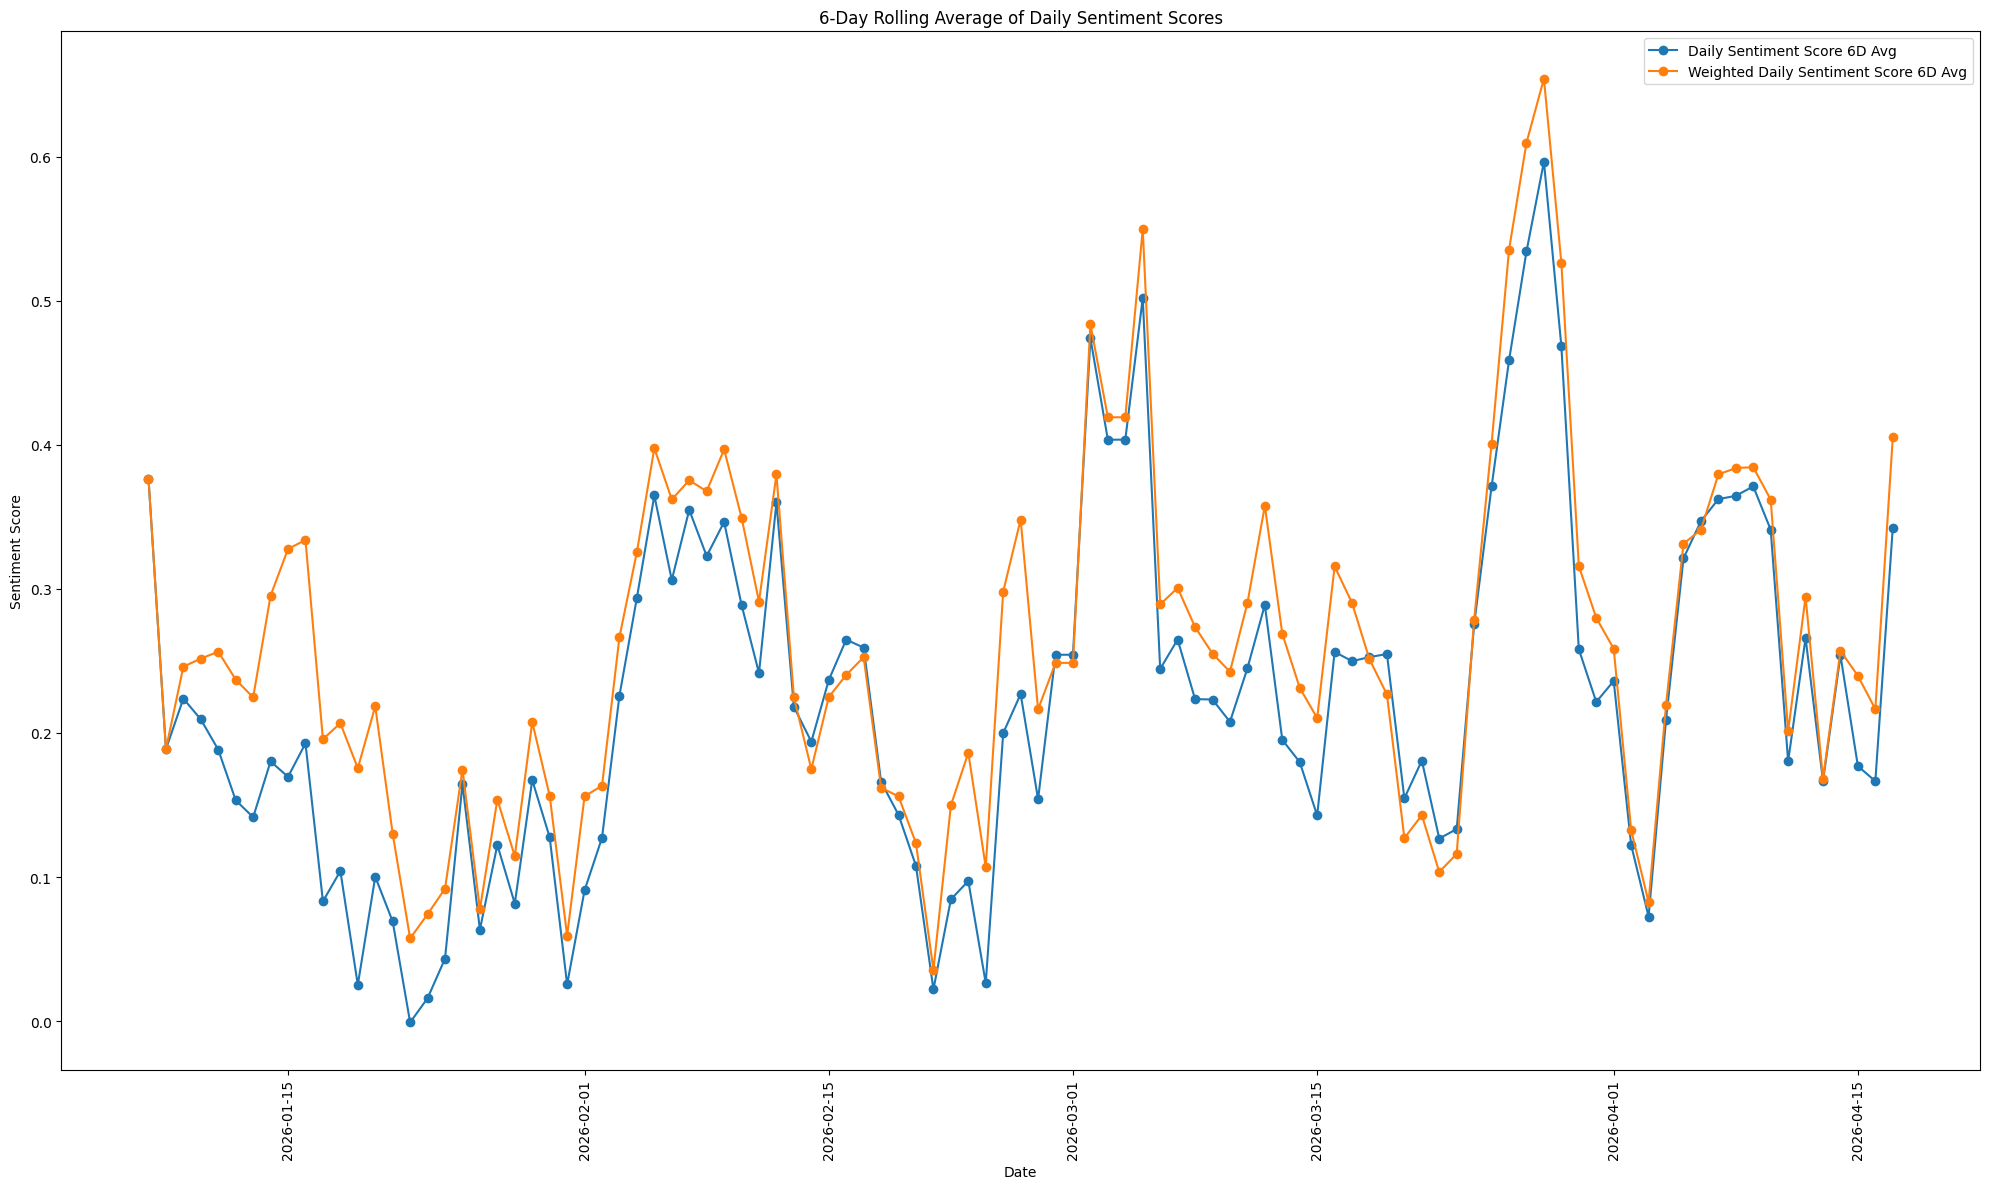

In [14]:
results_df = pd.read_csv("daily_news_sentiment_results.csv", index_col=0)

numeric_rows = [
    "daily_sentiment_score",
    "weighted_daily_sentiment_score",
    "n_articles",
    "inter_article_entropy",
    "inter_article_directional_entropy",
    "weighted_variance",
    "daily_sentiment_score_6d_avg",
    "weighted_daily_sentiment_score_6d_avg",
]

numeric_df = results_df.loc[numeric_rows].apply(pd.to_numeric, errors="coerce")

x = pd.to_datetime(numeric_df.columns)
y1 = numeric_df.loc["daily_sentiment_score_6d_avg"]
y2 = numeric_df.loc["weighted_daily_sentiment_score_6d_avg"]

plt.figure(figsize=(20, 12))
plt.plot(x, y1, label="Daily Sentiment Score 6D Avg", marker='o')
plt.plot(x, y2, label="Weighted Daily Sentiment Score 6D Avg", marker='o')
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.title("6-Day Rolling Average of Daily Sentiment Scores")
plt.legend()
plt.tight_layout()
plt.show()

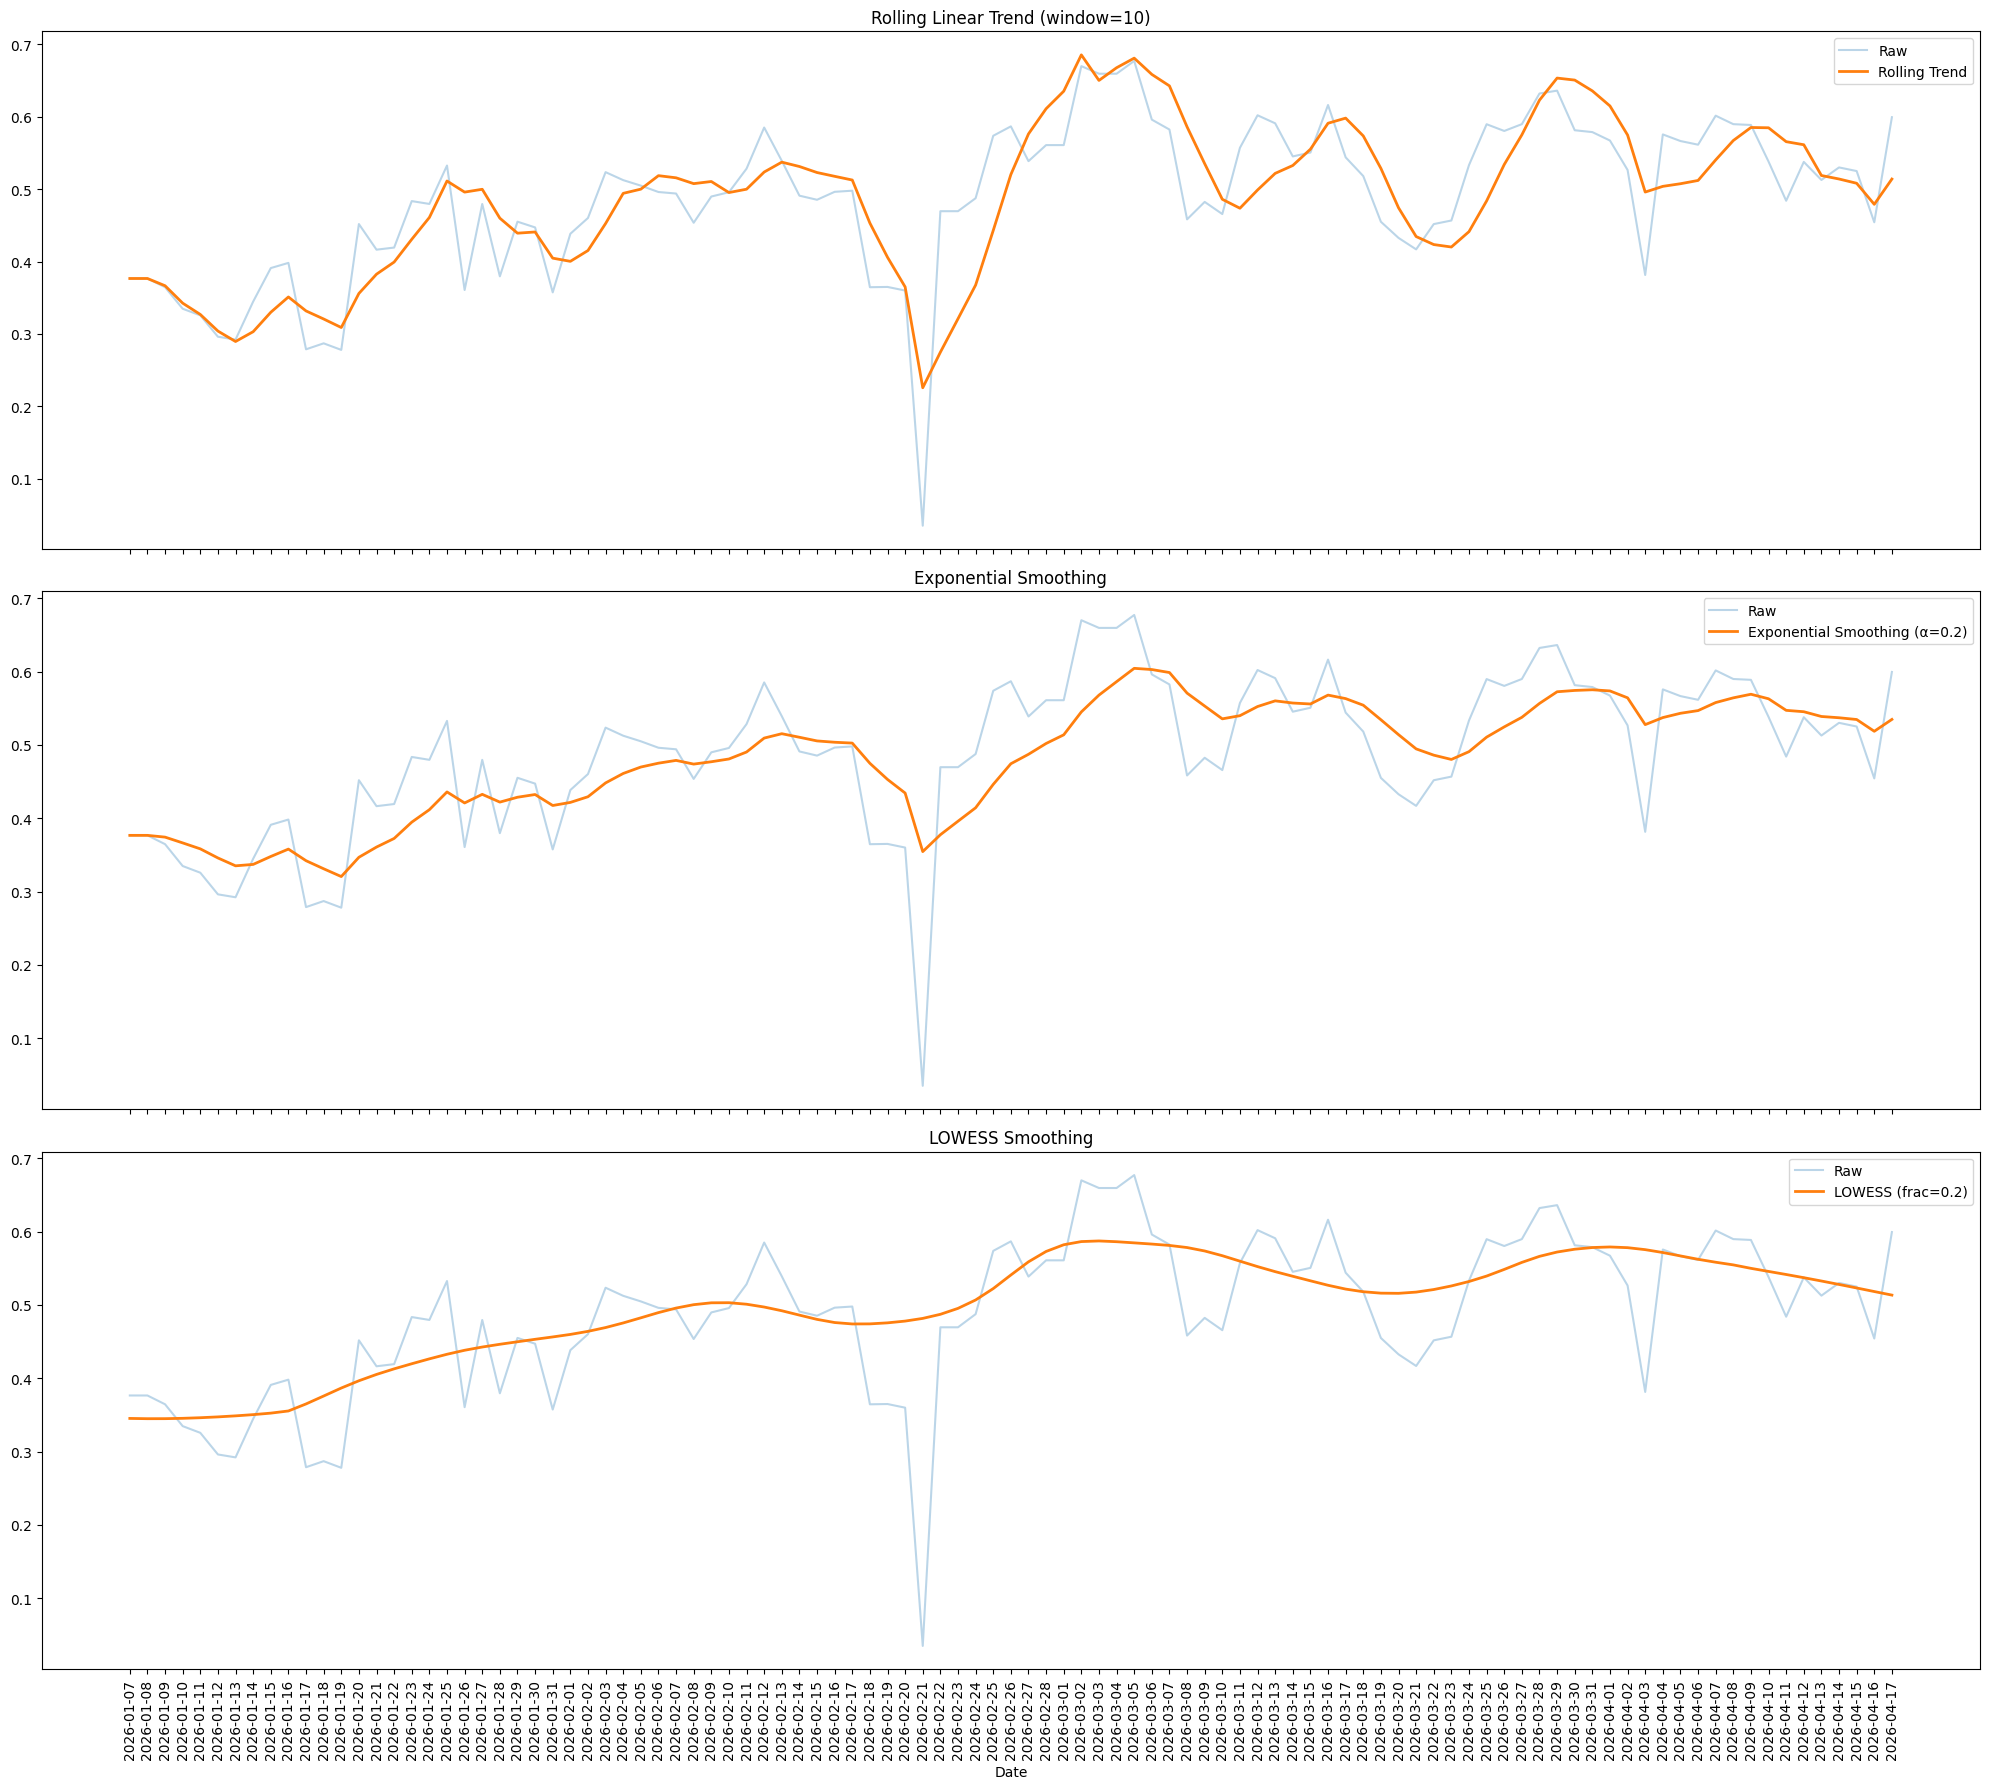

In [15]:
#nce and inter-article entropy to create a confidence-weighted rolling average score for the day, where days with fewer articles or more disagreement among articles are weighted less

def add_confidence_weighted_rolling(
    df,
    score_row="daily_sentiment_score",
    entropy_row="inter_article_entropy",
    count_row="n_articles",
    window=6,
    new_row_name="confidence_weighted_rolling"
):
    """
    Adds a confidence-weighted rolling average row to your results_df.

    Weight = n_articles * (1 - entropy)

    Parameters:
        df: pandas DataFrame (your results_df)
        score_row: row name for sentiment scores
        entropy_row: row name for entropy
        count_row: row name for number of articles
        window: rolling window size
        new_row_name: name of new row to create

    Returns:
        df with new row added
    """

    scores = df.loc[score_row].astype(float).values
    entropy = df.loc[entropy_row].astype(float).values
    counts = df.loc[count_row].astype(float).values

    # Replace NaNs safely
    entropy = np.nan_to_num(entropy, nan=1.0)  # max entropy → zero confidence
    counts = np.nan_to_num(counts, nan=0.0)
    scores = np.nan_to_num(scores, nan=0.0)

    # Confidence = 1 - entropy
    confidence = 1 - entropy

    # Final weights
    weights = counts * confidence

    rolling_vals = []

    for i in range(len(scores)):
        start = max(0, i - window + 1)

        v = scores[start:i+1]
        w = weights[start:i+1]

        w_sum = np.sum(w)

        if w_sum == 0:
            rolling_vals.append(np.nan)
        else:
            rolling_vals.append(np.sum(v * w) / w_sum)

    df.loc[new_row_name] = rolling_vals

    return df

results_df1 = results_df.copy()
results_df = add_confidence_weighted_rolling(
    results_df1,
    window=6,
    new_row_name="confidence_weighted_6d_avg"
)

results_df = add_confidence_weighted_rolling(
    results_df1,
    score_row="weighted_daily_sentiment_score",
    entropy_row="inter_article_directional_entropy",
    count_row="n_articles",
    window=6,
    new_row_name="confidence_weighted_weighted_6d_avg"
)

import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np

# --- Prepare data ---
dates = results_df.columns
y = results_df.loc["confidence_weighted_weighted_6d_avg"].astype(float).values

# --- Rolling regression trend ---
window = 10
trend = []

for i in range(len(y)):
    start = max(0, i - window + 1)
    x_local = np.arange(start, i+1)
    y_local = y[start:i+1]

    if len(x_local) < 2:
        trend.append(y[i])
        continue

    coef = np.polyfit(x_local, y_local, 1)
    trend.append(np.polyval(coef, i))

trend = np.array(trend)

# --- Exponential smoothing ---
def exp_smooth(y, alpha=0.2):
    s = np.zeros_like(y)
    s[0] = y[0]
    for i in range(1, len(y)):
        s[i] = alpha * y[i] + (1 - alpha) * s[i-1]
    return s

y_exp = exp_smooth(y, alpha=0.2)

# --- LOWESS ---
x = np.arange(len(y))
lowess_smoothed = lowess(y, x, frac=0.2)[:, 1]

# --- Plot everything in subplots ---
fig, axs = plt.subplots(3, 1, figsize=(20, 18), sharex=True)

# 1. Rolling regression
axs[0].plot(dates, y, alpha=0.3, label="Raw")
axs[0].plot(dates, trend, label="Rolling Trend", linewidth=2)
axs[0].set_title("Rolling Linear Trend (window=10)")
axs[0].legend()

# 2. Exponential smoothing
axs[1].plot(dates, y, alpha=0.3, label="Raw")
axs[1].plot(dates, y_exp, label="Exponential Smoothing (α=0.2)", linewidth=2)
axs[1].set_title("Exponential Smoothing")
axs[1].legend()

# 3. LOWESS
axs[2].plot(dates, y, alpha=0.3, label="Raw")
axs[2].plot(dates, lowess_smoothed, label="LOWESS (frac=0.2)", linewidth=2)
axs[2].set_title("LOWESS Smoothing")
axs[2].legend()

# formatting
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.tight_layout()
plt.show()


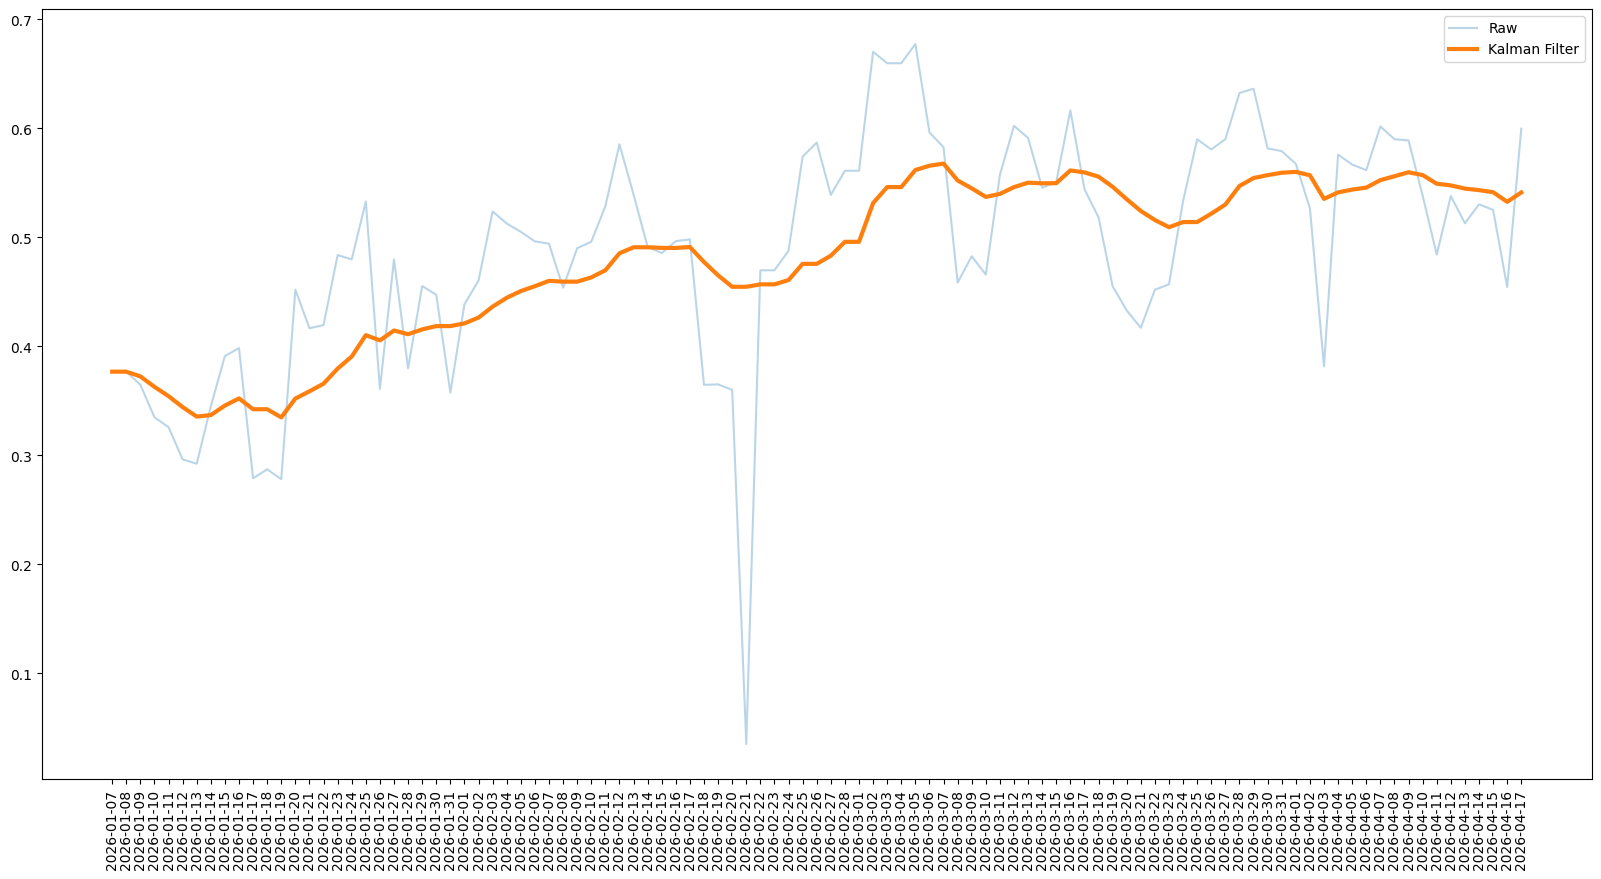

In [18]:
#kalman filter

def kalman_filter(y, R, Q=0.05):
    n = len(y)
    x = np.zeros(n)
    P = np.zeros(n)

    x[0] = y[0]
    P[0] = 1.0

    for t in range(1, n):
        x_pred = x[t-1]
        P_pred = P[t-1] + Q

        if np.isnan(y[t]) or np.isnan(R[t]):
            x[t] = x_pred
            P[t] = P_pred
            continue

        K = P_pred / (P_pred + R[t])
        x[t] = x_pred + K * (y[t] - x_pred)
        P[t] = (1 - K) * P_pred

    return x

y = results_df.loc["confidence_weighted_weighted_6d_avg"].astype(float).values

# confidence = inverse entropy
entropy = pd.to_numeric(results_df.loc["inter_article_entropy"], errors="coerce").values
R = entropy + 1e-6  # avoid zero

kalman = kalman_filter(y, R, Q=0.01)

plt.figure(figsize=(20, 10))
plt.plot(results_df.columns, y, alpha=0.3, label="Raw")
plt.plot(results_df.columns, kalman, label="Kalman Filter", linewidth=3)
plt.legend()
plt.xticks(rotation=90)
plt.show()


In [11]:
print(results_df.shape)
print(results_df.index[:10])
print(results_df.columns[:10])
print(results_df.dtypes.head())
print(results_df.loc["confidence_weighted_6d_avg"].head())
print(type(results_df.loc["confidence_weighted_6d_avg"].iloc[0]))

(11, 101)
Index(['articles', 'daily_sentiment_score', 'weighted_daily_sentiment_score',
       'n_articles', 'inter_article_entropy',
       'inter_article_directional_entropy', 'weighted_variance',
       'daily_sentiment_score_6d_avg', 'weighted_daily_sentiment_score_6d_avg',
       'confidence_weighted_6d_avg'],
      dtype='object')
Index(['2026-01-07', '2026-01-08', '2026-01-09', '2026-01-10', '2026-01-11',
       '2026-01-12', '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16'],
      dtype='object')
2026-01-07    object
2026-01-08    object
2026-01-09    object
2026-01-10    object
2026-01-11    object
dtype: object
2026-01-07    0.376589
2026-01-08    0.218808
2026-01-09    0.260393
2026-01-10    0.235897
2026-01-11    0.204708
Name: confidence_weighted_6d_avg, dtype: object
<class 'float'>
